# Real-data inspection, reports, and diagnostic plots

This notebook analyzes the public GSE147203 human–mouse mixture dataset
(GSM4228200; Marquina-Sánchez et al.). Transcripts assigned to the other
species provide an internal negative control, allowing direct measurement of
ambient RNA removal without a selected marker panel. The displayed tables and
figures were generated by executing the notebook on the archived benchmark
files.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ambidose as amdose

from ambidose.metrics import assign_majority_genome, leakage_by_species, umi_by_genome
from ambidose.pp import CHI_KEY, DROPLET_KEY, LAYER_OUT

ROOT = Path.cwd()
RAW_H5 = ROOT / "data/raw/GSE147203/GSM4228200_MF179_raw_gene_bc_matrices_h5.h5"
ANNOTATION = ROOT / "data/raw/GSE147203/GSM4228200_MF179_CellAnnotation_final.tsv.gz"
CELLBENDER_FILTERED = ROOT / "data/processed/gse147203_cellbender_fair_filtered.h5"

for path in (RAW_H5, ANNOTATION):
    if not path.exists():
        raise FileNotFoundError(path)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("raw:", RAW_H5)
print("annotation:", ANNOTATION)

raw: /home/lieber/AmbiDose/data/raw/GSE147203/GSM4228200_MF179_raw_gene_bc_matrices_h5.h5
annotation: /home/lieber/AmbiDose/data/raw/GSE147203/GSM4228200_MF179_CellAnnotation_final.tsv.gz


## Inspect the public raw matrix and author cell whitelist

In [2]:
# The annotation is a multi-column TSV, so inspect_input expects a barcode-only
# file. Inspect the matrix here and show the author barcode count explicitly.
inspection = amdose.inspect_input(RAW_H5, cell_barcodes=pd.read_csv(ANNOTATION, sep="\t")["barcode"].tolist())
pd.Series(inspection)

/home/lieber/miniforge3/envs/python/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/home/lieber/miniforge3/envs/python/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


kind                                                                          h5
input                          /home/lieber/AmbiDose/data/raw/GSE147203/GSM42...
raw_matrix                     /home/lieber/AmbiDose/data/raw/GSE147203/GSM42...
n_droplets                                                                737280
n_genes                                                                    60736
estimated_matrix_memory_gib                                             0.164812
empty_umi_max                                                                100
n_empty_candidates                                                        452550
whitelist_source               ['AAACCTGAGAACAATC', 'AAACCTGAGAGCCTAG', 'AAAC...
whitelist_mode                                                          external
feature_types                                         {'Gene Expression': 60736}
gene_symbol_style                                                   undetermined
obs_columns                 

## Construct the high-purity cell set used in the benchmark

In [3]:
raw = amdose.read_10x_h5(RAW_H5)
annotation = pd.read_csv(ANNOTATION, sep="\t")
author_barcodes = annotation["barcode"].astype(str).tolist()

amdose.classify_droplets(raw, cell_barcodes=author_barcodes, empty_umi_max=100)
amdose.estimate_chi(raw, sample_key=None)

cells = raw[raw.obs[DROPLET_KEY].astype(str) == "cell"].copy()
cells.var[CHI_KEY] = raw.var[CHI_KEY].to_numpy()
del raw

assign_majority_genome(cells)
genome_umi = umi_by_genome(cells)
purity = genome_umi.max(axis=1) / genome_umi.sum(axis=1).clip(lower=1)
cells = cells[purity >= 0.75].copy()
cells.obs[DROPLET_KEY] = "cell"
print(cells)
print(cells.obs["ambidose_species"].value_counts())

/home/lieber/miniforge3/envs/python/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/home/lieber/miniforge3/envs/python/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 6222 × 60736
    obs: 'n_umi', 'ambidose_droplet', 'ambidose_species', 'ambidose_species_frac'
    var: 'gene_ids', 'genome', 'ambidose_chi'
    uns: 'ambidose'
ambidose_species
hg19    4817
mm10    1405
Name: count, dtype: int64


## Run AmbiDose using species as the broad cell type

In [4]:
raw_leakage = leakage_by_species(cells).assign(stage="Raw")
amdose.denoise(cells, type_key="ambidose_species", sample_key=None)
den_leakage = leakage_by_species(cells, layer=LAYER_OUT).assign(stage="AmbiDose")
leakage = pd.concat([raw_leakage, den_leakage], ignore_index=True)
leakage[["stage", "species", "n_cells", "leakage_mean", "off_umi_mean", "total_umi_mean"]]

ambidose: estimating per-cell ambient dose...


ambidose: estimating per-cell ambient dose completed in 12.0s


ambidose: subtracting ambient counts...


ambidose: subtracting ambient counts completed in 8.9s


ambidose: denoise completed
  cells corrected:             6,222
  reference empty droplets:    0
  median estimated ambient:    9.4%
  median ambient UMI per cell: 537.7
  median dose actually removed: 18.0%
  corrected counts:            layers['ambidose_denoised']
ambidose: QC for estimated ambient fractions
  suitable for interpretation: 1,360 cells (21.9%)
  interpret with caution:      4,862 cells (78.1%)
    4,838: less than half of estimated dose removed
    24: removal exceeded dose or half of cell UMIs
ambidose: QC flags concern interpretation of obs['ambidose_rho']; they are not a recommendation to remove those cells. See the QC report or obs['ambidose_rho_trust'] for cell-level details.


,stage,species,n_cells,leakage_mean,off_umi_mean,total_umi_mean
0,Raw,hg19,4817,0.016921,86.217355,6119.515466
1,Raw,mm10,1405,0.035904,303.575089,9289.156584
2,AmbiDose,hg19,4817,0.000324,1.157775,5994.037990
3,AmbiDose,mm10,1405,0.000919,6.318149,8968.530961


## Cross-species leakage before and after correction

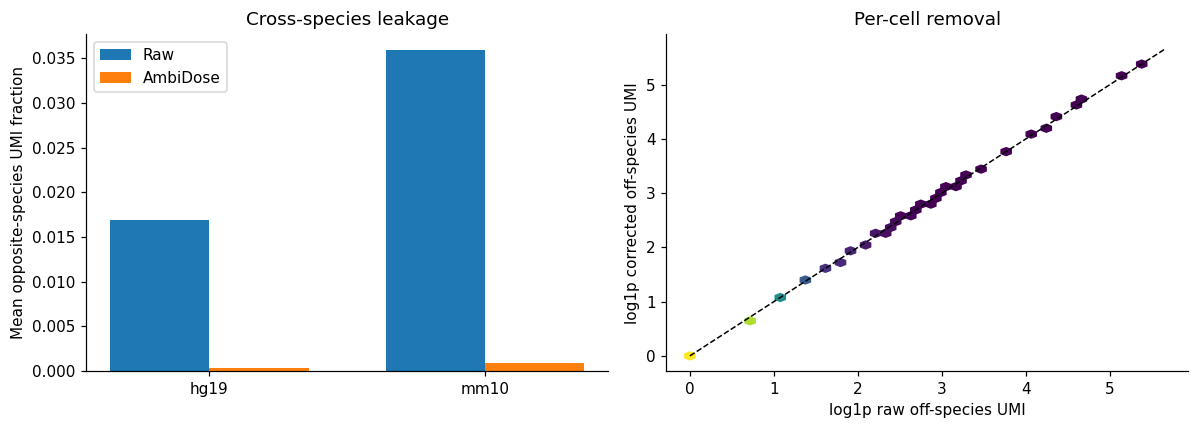

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for stage, group in leakage.groupby("stage", sort=False):
    axes[0].bar(
        np.arange(len(group)) + (-0.18 if stage == "Raw" else 0.18),
        group["leakage_mean"], width=0.36, label=stage,
    )
axes[0].set_xticks(range(len(raw_leakage)), raw_leakage["species"])
axes[0].set_ylabel("Mean opposite-species UMI fraction")
axes[0].set_title("Cross-species leakage")
axes[0].legend()

umi_raw = umi_by_genome(cells)
umi_den = umi_by_genome(cells, layer=LAYER_OUT)
species = cells.obs["ambidose_species"].astype(str)
off_raw = np.array([umi_raw.loc[b].drop(sp).sum() for b, sp in zip(cells.obs_names, species)])
off_den = np.array([umi_den.loc[b].drop(sp).sum() for b, sp in zip(cells.obs_names, species)])
axes[1].hexbin(np.log1p(off_raw), np.log1p(off_den), gridsize=45, mincnt=1, cmap="viridis")
limit = max(axes[1].get_xlim()[1], axes[1].get_ylim()[1])
axes[1].plot([0, limit], [0, limit], "k--", lw=1)
axes[1].set(xlabel="log1p raw off-species UMI", ylabel="log1p corrected off-species UMI", title="Per-cell removal")
fig.tight_layout()
plt.show()

## AmbiDose-specific diagnostic plots

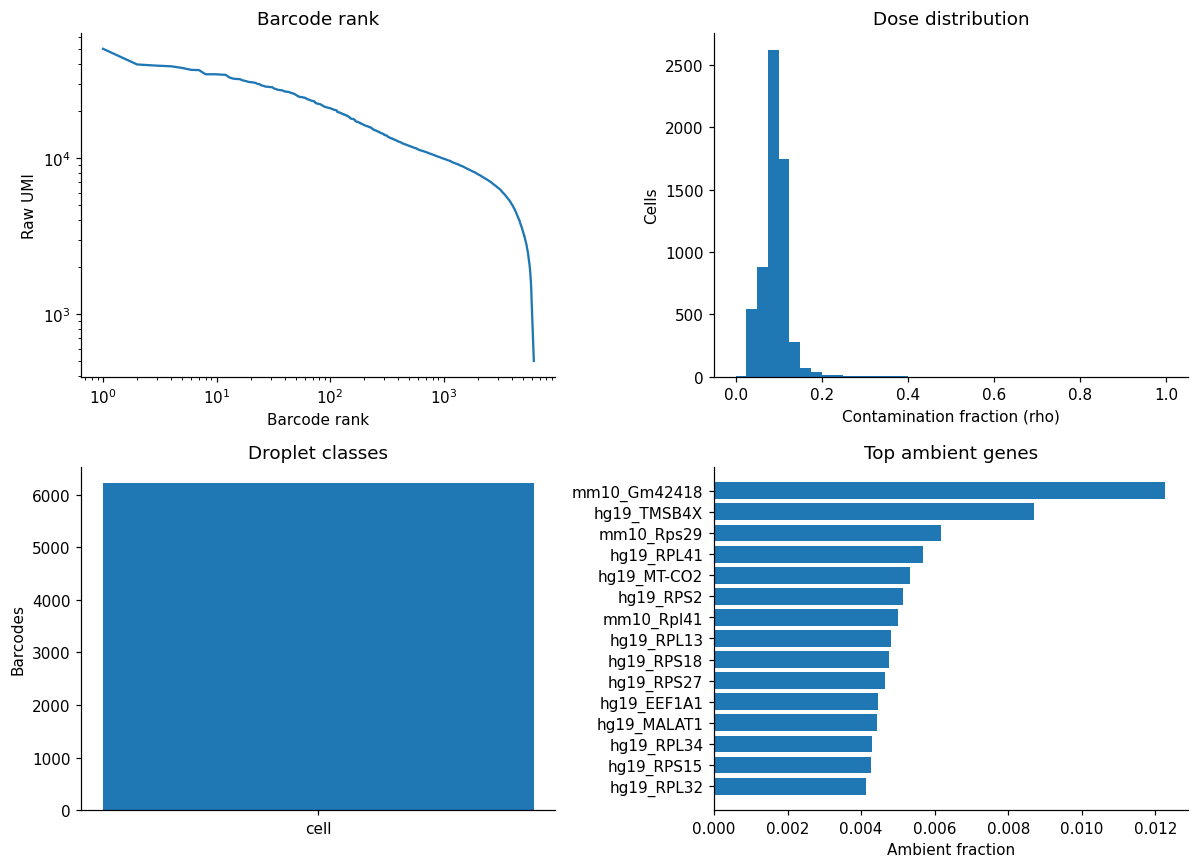

In [6]:
fig = amdose.pl.summary(cells)
plt.show()

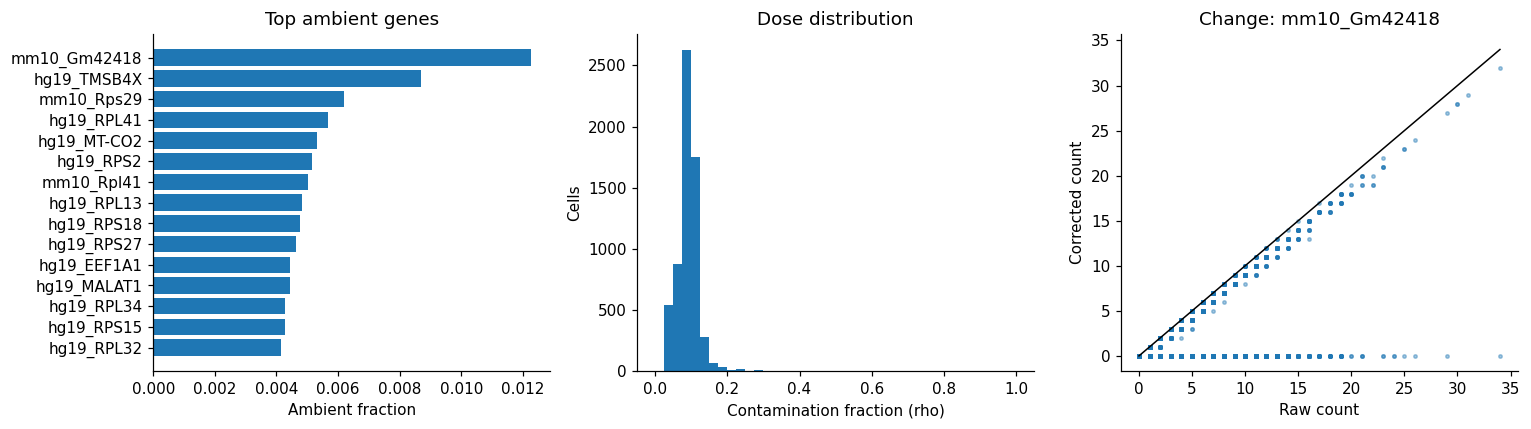

Top removed gene: mm10_Gm42418


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
amdose.pl.ambient_profile(cells, top=15, ax=axes[0])
amdose.pl.dose_distribution(cells, ax=axes[1])

summary = amdose.summarize(cells)
top_gene = summary["top_removed_genes"][0]["gene"]
amdose.pl.gene_change(cells, top_gene, ax=axes[2])
fig.tight_layout()
plt.show()
print("Top removed gene:", top_gene)

## Machine-readable summary and self-contained HTML report

In [8]:
summary = amdose.summarize(cells)
pd.Series({k: v for k, v in summary.items() if not isinstance(v, (list, dict))})

n_droplets                                                                        6222
n_genes                                                                          60736
n_cells                                                                           6222
n_empty                                                                              0
n_other                                                                              0
n_doublet                                                                            0
median_rho                                                                    0.093751
median_predicted_ambient_umi                                                537.742684
n_trust_ok                                                                        1360
n_trust_low_evidence                                                                 0
n_trust_ceiling_risk                                                                 0
n_trust_type_structure_risk                

In [9]:
report_path = Path("/tmp/gse147203_ambidose_report.html")
amdose.write_report(cells, report_path)
ready = amdose.analysis_ready(cells)
print("report:", report_path, "bytes:", report_path.stat().st_size)
print("analysis-ready:", ready)
print("X is corrected; raw counts layer:", "raw_counts" in ready.layers)

report: /tmp/gse147203_ambidose_report.html bytes: 172450
analysis-ready: AnnData object with n_obs × n_vars = 6222 × 60736
    obs: 'n_umi', 'ambidose_droplet', 'ambidose_species', 'ambidose_species_frac', 'ambidose_d', 'ambidose_rho', 'ambidose_removed_umi', 'ambidose_dose_execution_ratio', 'ambidose_removed_fraction', 'ambidose_rho_trust'
    var: 'gene_ids', 'genome', 'ambidose_chi', 'ambidose_removed_umi'
    uns: 'ambidose'
    layers: 'ambidose_denoised', 'raw_counts'
X is corrected; raw counts layer: True
